## Task 02
## Trends, and the spaghetti problem (gapminder.csv)
1,704 rows: 142 countries × 12 years (1952–2007, every 5 years). Columns: country, continent, year, lifeExp, pop, gdpPercap. No missing values — this one is clean, so there is nowhere to hide.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

path = 'week 01 dataset\gapminder.csv.'
df = pd.read_csv(path)

print(df.shape)
display(df.head())
print(df.isna().sum())

(1704, 6)


<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\M Saeed\AppData\Local\Temp\ipykernel_16260\1900208575.py:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  path = 'week 01 dataset\gapminder.csv.'


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64


## 1. Deliberately messy chart: all 142 countries
**Make the messy chart on purpose. Plot life expectancy over time as one line per country — all 142, with a legend. Keep it in your notebook and write down everything wrong with it.**

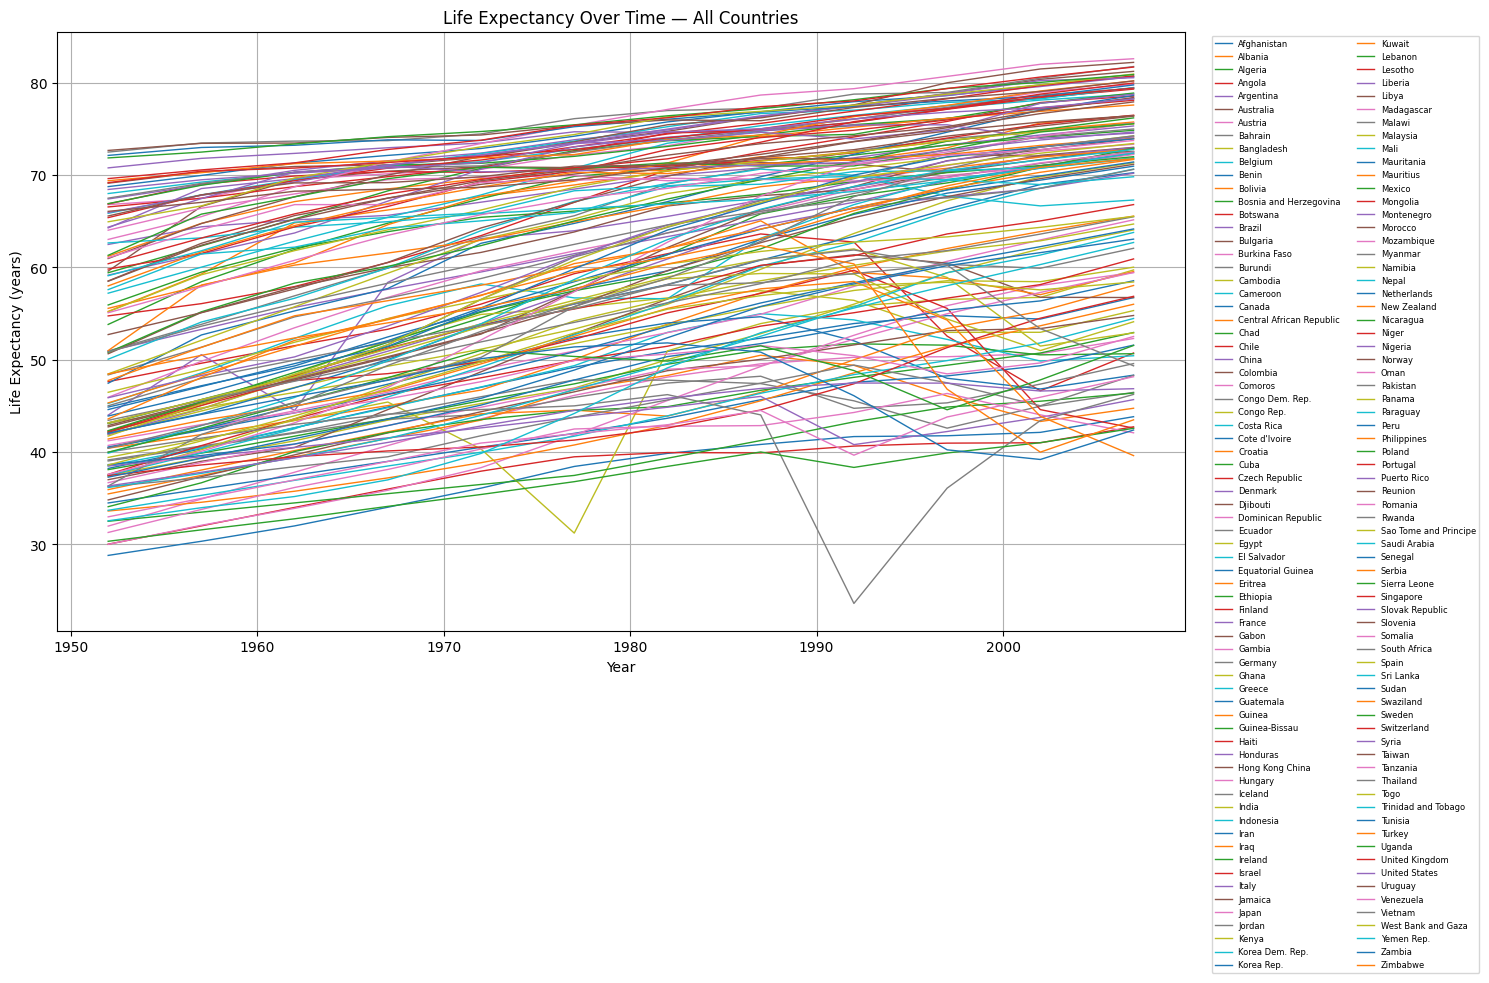

In [4]:
fig, ax = plt.subplots(figsize=(15, 9))

for country, group in df.groupby('country'):
    group = group.sort_values('year')
    ax.plot(group['year'], group['lifeExp'], label=country, linewidth=1)

ax.set_title('Life Expectancy Over Time — All Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

### What is wrong with the spaghetti chart?

- There are 142 lines, so individual trends are difficult to follow.
- The lines overlap heavily, especially within continents and similar life-expectancy ranges.
- The huge legend occupies a lot of space and is difficult to scan.
- Colour is used for too many categories, so the colours stop being useful as a visual encoding.
- It is hard to compare continents or see the overall pattern.
- Small but meaningful country-level differences can disappear inside the mass of lines.
- The chart has a high cognitive load: the reader must constantly match a line to a country name.

The chart is not technically wrong; it is simply a poor design for seeing the overall trend.

## 2(a). Fix by aggregating to continent
one line per continent instead of per country.

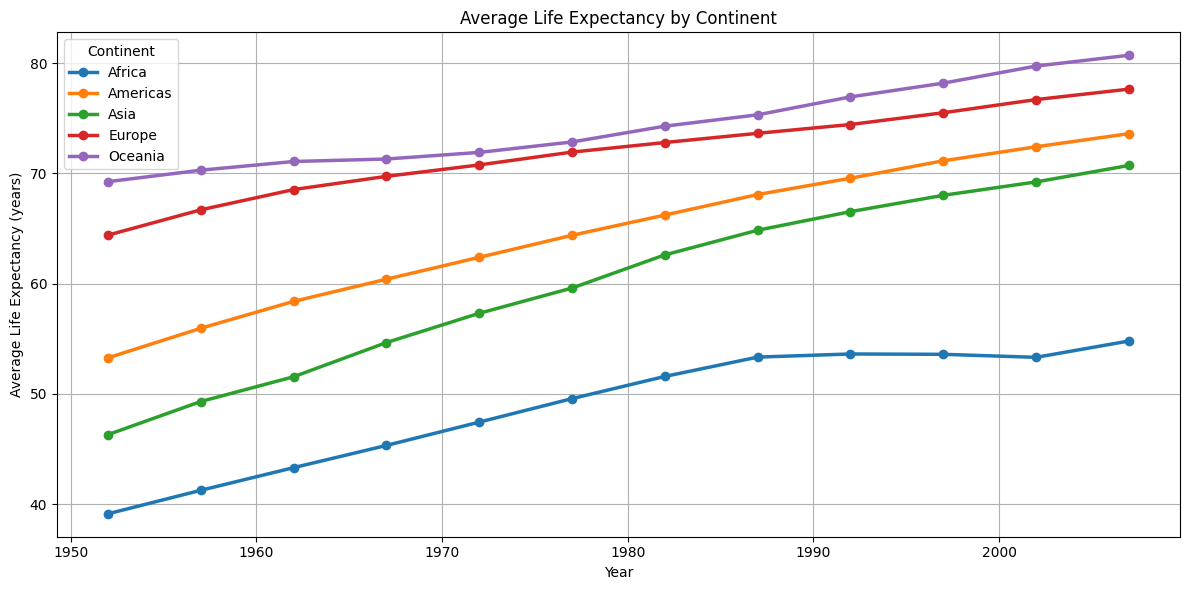

In [5]:
continent_life = (
    df.groupby(['continent', 'year'], as_index=False)['lifeExp']
      .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

for continent, group in continent_life.groupby('continent'):
    group = group.sort_values('year')
    ax.plot(group['year'], group['lifeExp'], marker='o', linewidth=2.5, label=continent)

ax.set_title('Average Life Expectancy by Continent')
ax.set_xlabel('Year')
ax.set_ylabel('Average Life Expectancy (years)')
ax.legend(title='Continent')
plt.tight_layout()
plt.show()

## 2(b). Fix by highlighting three countries

keep all 142 lines, but grey them out and colour only 3 countries you find interesting. Label those 3 directly on the chart, with no legend.

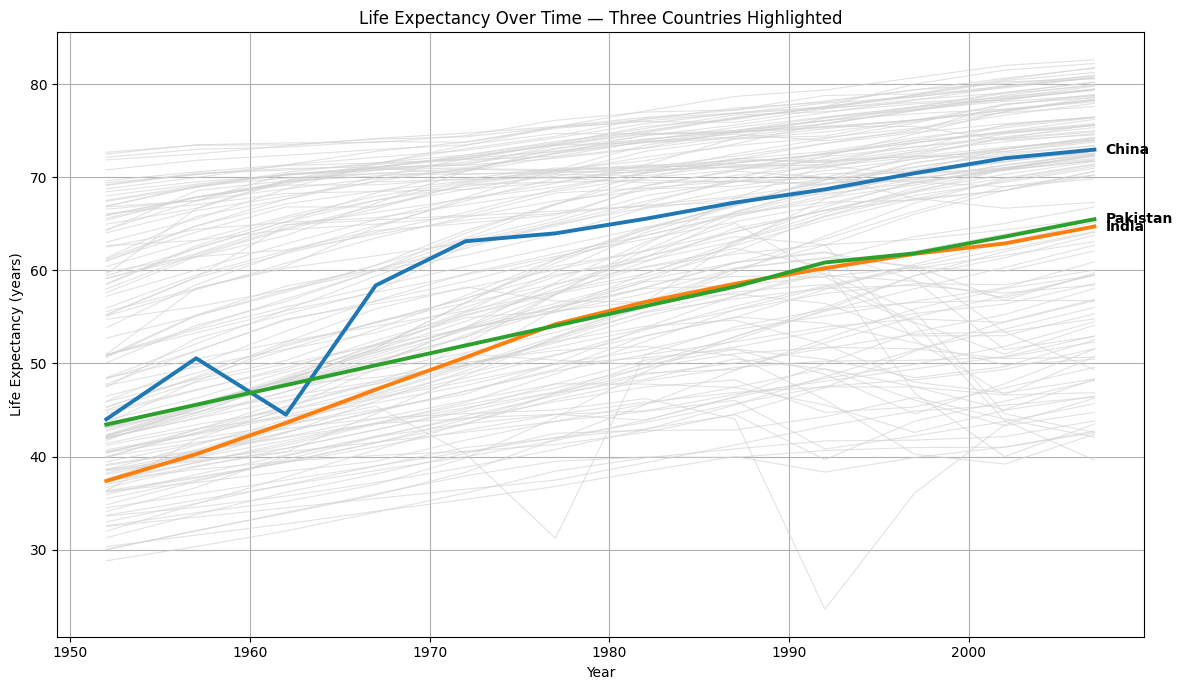

In [6]:
highlight = ['China', 'India', 'Pakistan']

fig, ax = plt.subplots(figsize=(12, 7))

# Background: all countries in grey
for country, group in df.groupby('country'):
    group = group.sort_values('year')
    if country not in highlight:
        ax.plot(group['year'], group['lifeExp'], color='lightgrey', linewidth=0.8, alpha=0.65)

# Highlighted countries
for country in highlight:
    group = df[df['country'] == country].sort_values('year')
    ax.plot(group['year'], group['lifeExp'], linewidth=2.8, label=country)

# Direct labels at the final year
for country in highlight:
    group = df[df['country'] == country].sort_values('year')
    last = group.iloc[-1]
    ax.annotate(
        country,
        xy=(last['year'], last['lifeExp']),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Life Expectancy Over Time — Three Countries Highlighted')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

## 3. Comparison of the two fixes

**Aggregation** is best for seeing the broad continental story. It reduces 142 country lines to a small number of lines, making overall trends, differences between continents, and changes over time much easier to compare. However, aggregation hides variation between individual countries. Two countries can have very different trajectories while their continent's average looks smooth.

**Highlighting** keeps the full country-level context while drawing attention to three selected countries. It allows us to see the detailed trajectories of those countries and compare them against the distribution of all other countries. The trade-off is that it does not give a clean summary of continental trends, and the choice of the three highlighted countries is selective.

In short: **aggregation simplifies the whole dataset but loses country-level detail; highlighting preserves the dataset's detail but focuses attention on only a few countries.**

## 4. Has the gap between the richest and poorest countries narrowed since 1952?

For this question, use **GDP per capita** because 'richest' and 'poorest' refer to economic prosperity. For each year, calculate the maximum and minimum `gdpPercap`, then calculate their ratio:

`richest GDP per capita / poorest GDP per capita`

A ratio close to 1 means the extremes are closer together; a larger ratio means a wider gap. A log y-axis is appropriate because GDP per capita is highly skewed and the ratio can span a large range.

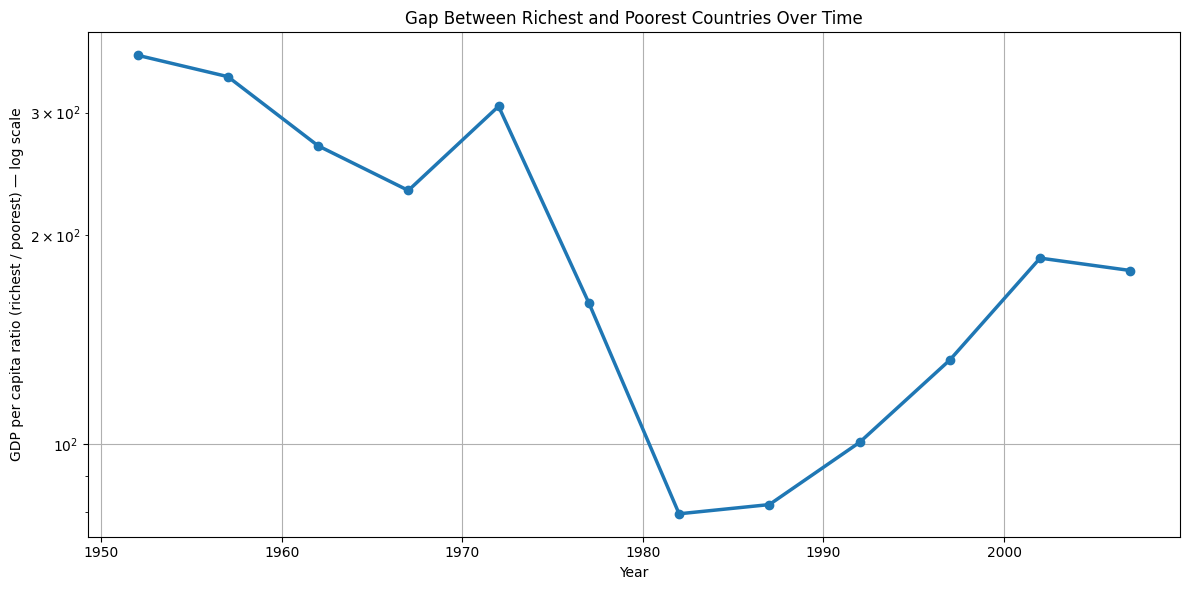

 year   richest  poorest  ratio
 1952 108382.35   298.85 362.67
 1957 113523.13   336.00 337.87
 1962  95458.11   355.20 268.74
 1967  80894.88   349.00 231.79
 1972 109347.87   357.00 306.30
 1977  59265.48   371.00 159.75
 1982  33693.18   424.00  79.47
 1987  31540.97   385.00  81.92
 1992  34932.92   347.00 100.67
 1997  41283.16   312.19 132.24
 2002  44683.98   241.17 185.28
 2007  49357.19   277.55 177.83
1952 ratio: 362.67
2007 ratio: 177.83
Change in ratio: -184.84


In [7]:
gap = (
    df.groupby('year')['gdpPercap']
      .agg(richest='max', poorest='min')
      .reset_index()
)
gap['ratio'] = gap['richest'] / gap['poorest']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(gap['year'], gap['ratio'], marker='o', linewidth=2.5)

ax.set_yscale('log')
ax.set_title('Gap Between Richest and Poorest Countries Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('GDP per capita ratio (richest / poorest) — log scale')
plt.tight_layout()
plt.show()

print(gap[['year', 'richest', 'poorest', 'ratio']].round(2).to_string(index=False))

first_ratio = gap.iloc[0]['ratio']
last_ratio = gap.iloc[-1]['ratio']
print(f'1952 ratio: {first_ratio:.2f}')
print(f'2007 ratio: {last_ratio:.2f}')
print(f'Change in ratio: {last_ratio - first_ratio:.2f}')

## 5. GDP per capita is highly skewed

First inspect the raw distribution.

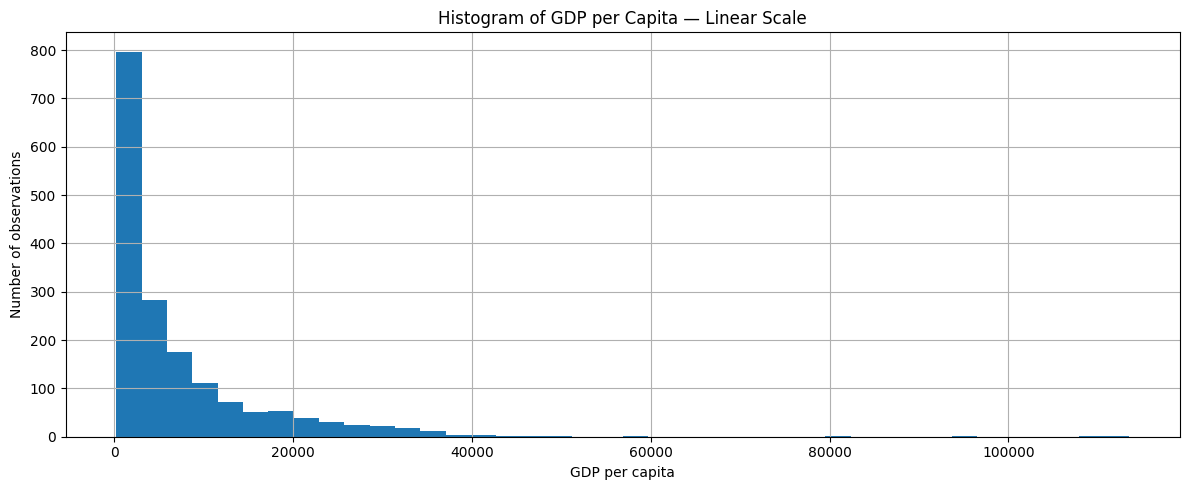

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['gdpPercap'], bins=40)
ax.set_title('Histogram of GDP per Capita — Linear Scale')
ax.set_xlabel('GDP per capita')
ax.set_ylabel('Number of observations')
plt.tight_layout()
plt.show()

### Histogram with a log x-axis

A logarithmic scale does not change the underlying GDP values. It changes the spacing of the x-axis so that multiplicative differences are represented more evenly. Very large GDP values are compressed, while smaller values receive more visual space.

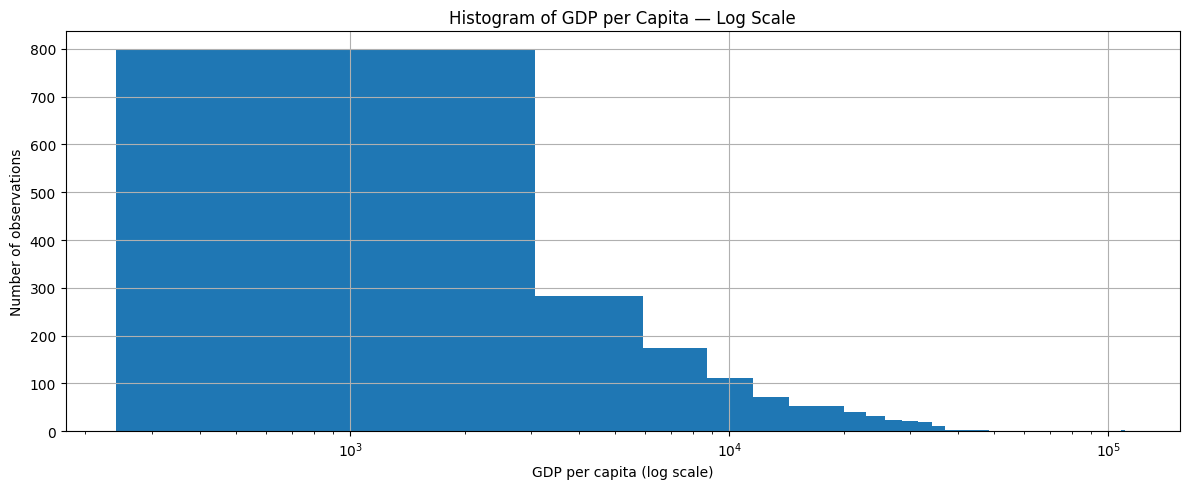

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['gdpPercap'], bins=40)
ax.set_xscale('log')
ax.set_title('Histogram of GDP per Capita — Log Scale')
ax.set_xlabel('GDP per capita (log scale)')
ax.set_ylabel('Number of observations')
plt.tight_layout()
plt.show()

### Decision about the log scale

The log scale should be used when visualising `gdpPercap` because the variable is strongly right-skewed. On the ordinary linear scale, observations with very high GDP per capita stretch the axis and make much of the lower and middle distribution difficult to inspect. The log scale makes the distribution easier to compare across orders of magnitude. The raw values are still unchanged; only their visual spacing is transformed.